In [1]:
import pandas as pd

fact = pd.read_csv("apollo_appointments_fact.csv")
doc = pd.read_csv("apollo_doctors_dim.csv")

In [2]:
fact.shape

(75000, 52)

In [3]:
fact.head()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_day,appointment_day_of_week,appointment_month,appointment_quarter,appointment_year,appointment_hour,...,insurance_coverage,insurance_provider,insurance_covered_amount,patient_out_of_pocket,revenue_realized,payment_mode,wait_time_minutes,consultation_duration_min,patient_satisfaction_score,doctor_utilization_pct
0,APPT5000001,PAT117608,DOC1035,2023-11-15,Wednesday,2,11,Q4,2023,15,...,No,NaN,0,2700,2700,UPI,11.0,40.0,4.8,84.2
1,APPT5000002,PAT128732,DOC1049,2023-03-13,Monday,0,3,Q1,2023,9,...,No,NaN,0,1400,1400,UPI,21.0,18.0,4.1,64.5
2,APPT5000003,PAT137532,DOC1033,2022-02-07,Monday,0,2,Q1,2022,17,...,No,NaN,0,600,600,Net Banking,6.0,6.0,5.0,75.6
3,APPT5000004,PAT113284,DOC1288,2023-11-20,Monday,0,11,Q4,2023,17,...,No,NaN,0,1275,1275,UPI,2.0,25.0,4.4,68.6
4,APPT5000005,PAT107443,DOC1064,2024-02-02,Friday,4,2,Q1,2024,19,...,No,NaN,0,1700,1700,Cash,7.0,13.0,3.5,67.7


In [4]:
doc.head()

,doctor_id,doctor_name,specialty,qualification,experience_years,city,state,hospital_name,consultation_fee,rating,total_reviews,available_days,avg_slot_duration_min,accepts_insurance,teleconsult_enabled
0,DOC1001,Dr. Deepa Sharma,Urology,"MBBS, MCh",12,Bengaluru,Karnataka,Apollo Hospital Bannerghatta,2300,4.4,1502,Mon-Fri,15,Yes,No
1,DOC1002,Dr. Venkatesan Khan,Paediatrics,"MBBS, MS, FRCS",25,Chandigarh,Punjab,Apollo Clinic Sector 8,1200,4.5,2453,Mon-Sat,10,Yes,Yes
2,DOC1003,Dr. Pradeep Menon,General Physician,"MBBS, DM",13,Mumbai,Maharashtra,Apollo Clinic Andheri,700,4.7,995,Mon-Wed-Fri-Sat,15,No,No
3,DOC1004,Dr. Vivek Mathew,General Physician,"MBBS, MD",31,Mumbai,Maharashtra,Apollo Hospital Navi Mumbai,1000,4.9,666,Mon-Wed-Fri-Sat,20,Yes,Yes
4,DOC1005,Dr. Savita Philip,General Physician,"MBBS, MD, PhD",5,Mumbai,Maharashtra,Apollo Hospital Navi Mumbai,600,4.5,1383,Mon-Sat,30,Yes,Yes


In [5]:
fact.info()

<class 'pandas.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 52 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   appointment_id              75000 non-null  str    
 1   patient_id                  75000 non-null  str    
 2   doctor_id                   75000 non-null  str    
 3   appointment_date            75000 non-null  str    
 4   appointment_day             75000 non-null  str    
 5   appointment_day_of_week     75000 non-null  int64  
 6   appointment_month           75000 non-null  int64  
 7   appointment_quarter         75000 non-null  str    
 8   appointment_year            75000 non-null  int64  
 9   appointment_hour            75000 non-null  int64  
 10  appointment_minute          75000 non-null  int64  
 11  time_slot                   75000 non-null  str    
 12  time_of_day                 75000 non-null  str    
 13  booking_date                75000 non-null

In [6]:
doc.info()

<class 'pandas.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   doctor_id              320 non-null    str    
 1   doctor_name            320 non-null    str    
 2   specialty              320 non-null    str    
 3   qualification          320 non-null    str    
 4   experience_years       320 non-null    int64  
 5   city                   320 non-null    str    
 6   state                  320 non-null    str    
 7   hospital_name          320 non-null    str    
 8   consultation_fee       320 non-null    int64  
 9   rating                 320 non-null    float64
 10  total_reviews          320 non-null    int64  
 11  available_days         320 non-null    str    
 12  avg_slot_duration_min  320 non-null    int64  
 13  accepts_insurance      320 non-null    str    
 14  teleconsult_enabled    320 non-null    str    
dtypes: float64(1), in

In [7]:
fact['appointment_date'] = pd.to_datetime(fact['appointment_date'])
fact['booking_date'] = pd.to_datetime(fact['booking_date'])

In [8]:
fact.dtypes['appointment_date']

dtype('<M8[us]')

In [9]:
fact['appointment_date'].min()
fact['appointment_date'].max()

Timestamp('2024-12-31 00:00:00')

In [10]:
print(fact['appointment_date'].min())
print(fact['appointment_date'].max())

2022-01-01 00:00:00
2024-12-31 00:00:00


In [11]:
fact['patient_chronic_condition'] = fact['patient_chronic_condition'].fillna('None')
fact['membership_type'] = fact['membership_type'].fillna('None')
fact['insurance_provider'] = fact['insurance_provider'].fillna('None')
fact['cancellation_reason'] = fact['cancellation_reason'].fillna('None')

In [12]:
fact['patient_chronic_condition'].isnull().sum()

np.int64(0)

In [13]:
print(fact['patient_chronic_condition'].isnull().sum())
print(fact['membership_type'].isnull().sum())
print(fact['insurance_provider'].isnull().sum())
print(fact['cancellation_reason'].isnull().sum())

0
0
0
0


In [14]:
print(fact.duplicated().sum())
print(fact['appointment_id'].duplicated().sum())

0
0


In [15]:
merged = fact.merge(doc, on='doctor_id', how='left', suffixes=('', '_doc'))

In [16]:
merged.shape

(75000, 66)

In [17]:
merged.columns.tolist()

['appointment_id',
 'patient_id',
 'doctor_id',
 'appointment_date',
 'appointment_day',
 'appointment_day_of_week',
 'appointment_month',
 'appointment_quarter',
 'appointment_year',
 'appointment_hour',
 'appointment_minute',
 'time_slot',
 'time_of_day',
 'booking_date',
 'booking_lead_days',
 'booking_channel',
 'appointment_type',
 'specialty',
 'city',
 'state',
 'hospital_name',
 'patient_age',
 'age_group',
 'patient_gender',
 'patient_city_tier',
 'patient_chronic_condition',
 'apollo_member',
 'membership_type',
 'reminder_type',
 'reminders_sent',
 'patient_prior_visits',
 'patient_prior_no_shows',
 'is_first_visit',
 'repeat_visit',
 'visit_reason',
 'appointment_status',
 'no_show',
 'no_show_flag',
 'cancellation_reason',
 'consultation_fee',
 'discount_pct',
 'actual_fee_charged',
 'insurance_coverage',
 'insurance_provider',
 'insurance_covered_amount',
 'patient_out_of_pocket',
 'revenue_realized',
 'payment_mode',
 'wait_time_minutes',
 'consultation_duration_min',
 '

In [18]:
(merged['specialty'] != merged['specialty_doc']).sum()

np.int64(0)

In [19]:
merged['is_weekend'] = merged['appointment_day_of_week'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

In [20]:
merged['is_weekend'].value_counts()

is_weekend
Weekday    53367
Weekend    21633
Name: count, dtype: int64

In [21]:
def lead_time_bucket(days):
    if days == 0:
        return 'Same Day'
    elif days <= 3:
        return '1-3 Days'
    elif days <= 7:
        return '4-7 Days'
    else:
        return '8-30 Days'

merged['lead_time_group'] = merged['booking_lead_days'].apply(lead_time_bucket)

In [22]:
merged['lead_time_group'].value_counts()

lead_time_group
1-3 Days     26302
Same Day     20810
4-7 Days     16442
8-30 Days    11446
Name: count, dtype: int64

In [23]:
monthly_volume = merged.groupby(['appointment_year', 'appointment_month']).size()
print(monthly_volume)

appointment_year  appointment_month
2022              1                    2426
                  2                    2012
                  3                    2085
                  4                    1926
                  5                    2033
                  6                    1823
                  7                    1833
                  8                    1835
                  9                    2115
                  10                   2206
                  11                   2299
                  12                   2275
2023              1                    2371
                  2                    2013
                  3                    2103
                  4                    1964
                  5                    2002
                  6                    1896
                  7                    1884
                  8                    1785
                  9                    2038
                  10                   2

In [24]:
quarterly_volume = merged.groupby(['appointment_year', 'appointment_quarter']).size()
print(quarterly_volume)

appointment_year  appointment_quarter
2022              Q1                     6523
                  Q2                     5782
                  Q3                     5783
                  Q4                     6780
2023              Q1                     6487
                  Q2                     5862
                  Q3                     5707
                  Q4                     6998
2024              Q1                     6538
                  Q2                     5899
                  Q3                     5777
                  Q4                     6864
dtype: int64


In [25]:
monthly_volume_df = monthly_volume.reset_index(name='appointment_count')
monthly_volume_df.head()

,appointment_year,appointment_month,appointment_count
0,2022,1,2426
1,2022,2,2012
2,2022,3,2085
3,2022,4,1926
4,2022,5,2033


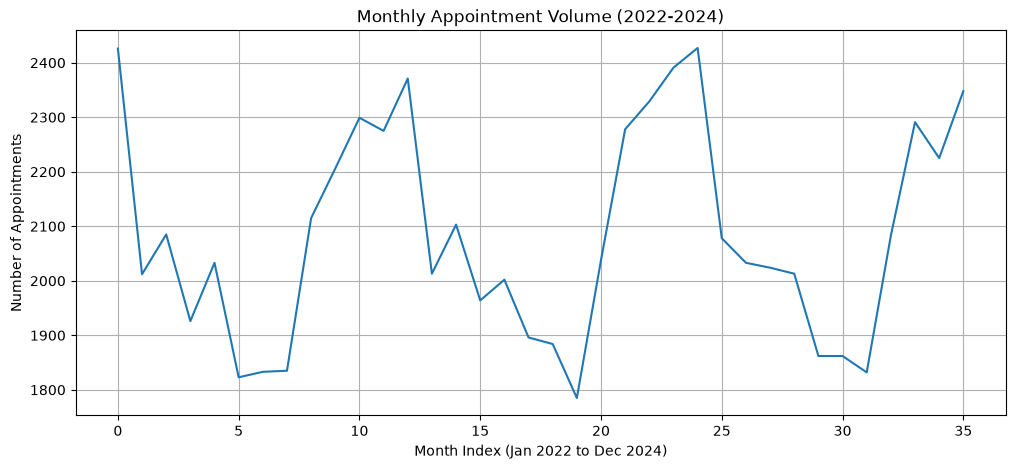

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(monthly_volume_df.index, monthly_volume_df['appointment_count'])
plt.title('Monthly Appointment Volume (2022-2024)')
plt.xlabel('Month Index (Jan 2022 to Dec 2024)')
plt.ylabel('Number of Appointments')
plt.grid(True)
plt.show()

In [27]:
status_counts = merged['appointment_status'].value_counts()
status_pct = merged['appointment_status'].value_counts(normalize=True) * 100

print(status_counts)
print(status_pct)

appointment_status
Completed    55275
No-Show      11584
Cancelled     5793
Scheduled     2348
Name: count, dtype: int64
appointment_status
Completed    73.700000
No-Show      15.445333
Cancelled     7.724000
Scheduled     3.130667
Name: proportion, dtype: float64


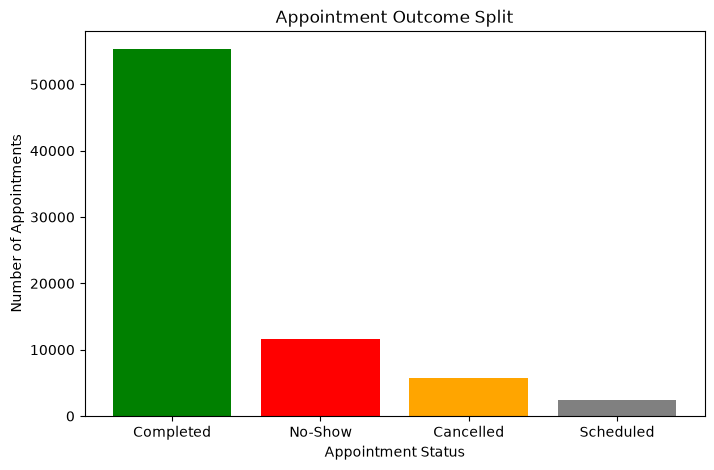

In [28]:
plt.figure(figsize=(8, 5))
plt.bar(status_counts.index, status_counts.values, color=['green', 'red', 'orange', 'grey'])
plt.title('Appointment Outcome Split')
plt.xlabel('Appointment Status')
plt.ylabel('Number of Appointments')
plt.show()

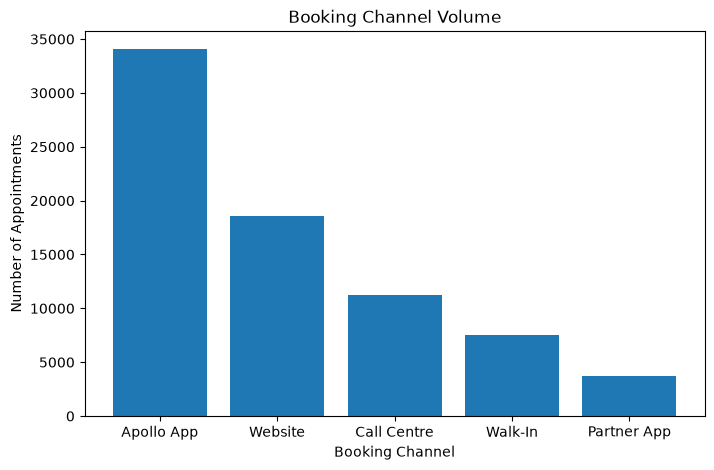

In [29]:
channel_counts = merged['booking_channel'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(channel_counts.index, channel_counts.values)
plt.title('Booking Channel Volume')
plt.xlabel('Booking Channel')
plt.ylabel('Number of Appointments')
plt.show()

In [30]:
print(channel_counts)

booking_channel
Apollo App     34042
Website        18545
Call Centre    11201
Walk-In         7501
Partner App     3711
Name: count, dtype: int64


In [31]:
channel_counts = merged['booking_channel'].value_counts()
print(channel_counts)

booking_channel
Apollo App     34042
Website        18545
Call Centre    11201
Walk-In         7501
Partner App     3711
Name: count, dtype: int64


In [32]:
eligible = merged[merged['appointment_status'] != 'Scheduled']

In [33]:
eligible['appointment_status'].value_counts()

appointment_status
Completed    55275
No-Show      11584
Cancelled     5793
Name: count, dtype: int64

In [34]:
specialty_noshow = eligible.groupby('specialty')['no_show_flag'].mean() * 100
specialty_noshow = specialty_noshow.sort_values(ascending=False)
print(specialty_noshow)

specialty
Psychiatry           24.517241
Dermatology          21.252974
ENT                  18.959893
Endocrinology        17.539526
Ophthalmology        16.210119
General Physician    15.513381
Pulmonology          15.457042
Orthopaedics         14.947407
Gastroenterology     14.918876
Urology              14.401440
Gynaecology          14.257078
Cardiology           14.027654
Paediatrics          12.223120
Neurology            10.691302
Name: no_show_flag, dtype: float64


In [35]:
city_noshow = eligible.groupby('city')['no_show_flag'].mean() * 100
city_noshow = city_noshow.sort_values(ascending=False)
print(city_noshow)

city
Lucknow       17.194269
Mumbai        17.043353
Delhi         16.858900
Bhopal        16.791604
Kolkata       16.365550
Kochi         16.282528
Ahmedabad     16.176471
Jaipur        16.170373
Hyderabad     16.046479
Bengaluru     15.426106
Chandigarh    15.087282
Chennai       14.995524
Coimbatore    14.153562
Indore        14.146114
Pune          13.295086
Name: no_show_flag, dtype: float64


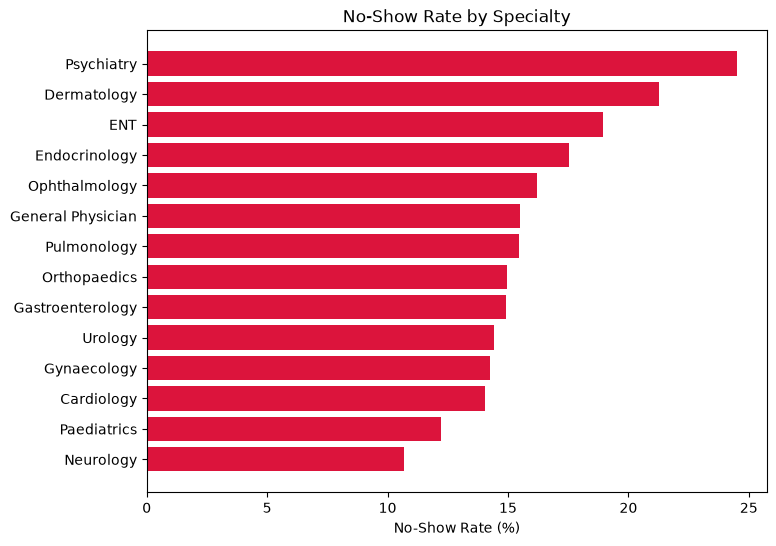

In [36]:
plt.figure(figsize=(8, 6))
plt.barh(specialty_noshow.index, specialty_noshow.values, color='crimson')
plt.title('No-Show Rate by Specialty')
plt.xlabel('No-Show Rate (%)')
plt.gca().invert_yaxis()
plt.show()

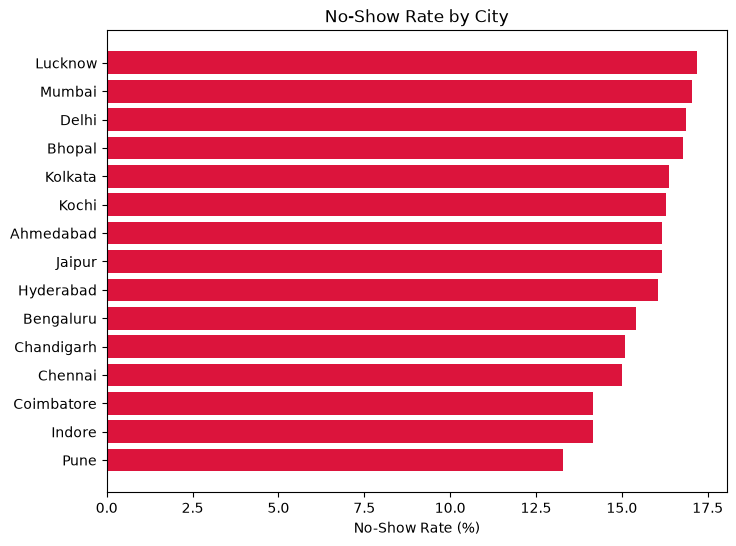

In [37]:
plt.figure(figsize=(8, 6))
plt.barh(city_noshow.index, city_noshow.values, color='crimson')
plt.title('No-Show Rate by City')
plt.xlabel('No-Show Rate (%)')
plt.gca().invert_yaxis()
plt.show()

In [38]:
leadtime_noshow = eligible.groupby('lead_time_group')['no_show_flag'].mean() * 100
print(leadtime_noshow)

lead_time_group
1-3 Days     14.331698
4-7 Days     16.499969
8-30 Days    19.072072
Same Day     15.822597
Name: no_show_flag, dtype: float64


In [39]:
order = ['Same Day', '1-3 Days', '4-7 Days', '8-30 Days']
leadtime_noshow = leadtime_noshow.reindex(order)
print(leadtime_noshow)

lead_time_group
Same Day     15.822597
1-3 Days     14.331698
4-7 Days     16.499969
8-30 Days    19.072072
Name: no_show_flag, dtype: float64


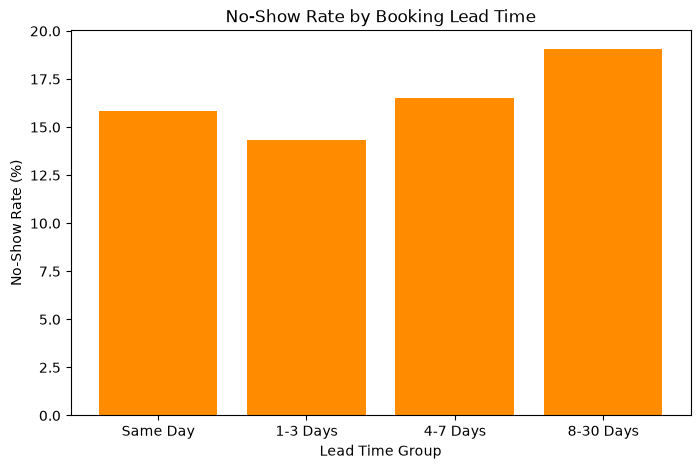

In [40]:
plt.figure(figsize=(8, 5))
plt.bar(leadtime_noshow.index, leadtime_noshow.values, color='darkorange')
plt.title('No-Show Rate by Booking Lead Time')
plt.xlabel('Lead Time Group')
plt.ylabel('No-Show Rate (%)')
plt.show()

In [41]:
timeofday_noshow = eligible.groupby('time_of_day')['no_show_flag'].mean() * 100
print(timeofday_noshow)

time_of_day
Afternoon    17.752142
Evening      18.367347
Morning      13.728921
Name: no_show_flag, dtype: float64


In [42]:
weekend_noshow = eligible.groupby('is_weekend')['no_show_flag'].mean() * 100
print(weekend_noshow)

is_weekend
Weekday    14.838298
Weekend    18.679795
Name: no_show_flag, dtype: float64


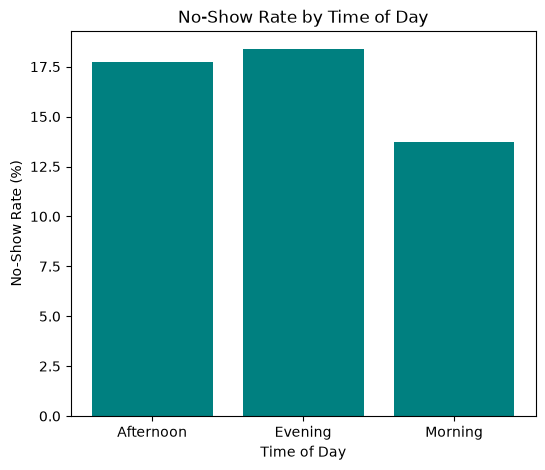

In [43]:
plt.figure(figsize=(6, 5))
plt.bar(timeofday_noshow.index, timeofday_noshow.values, color='teal')
plt.title('No-Show Rate by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('No-Show Rate (%)')
plt.show()

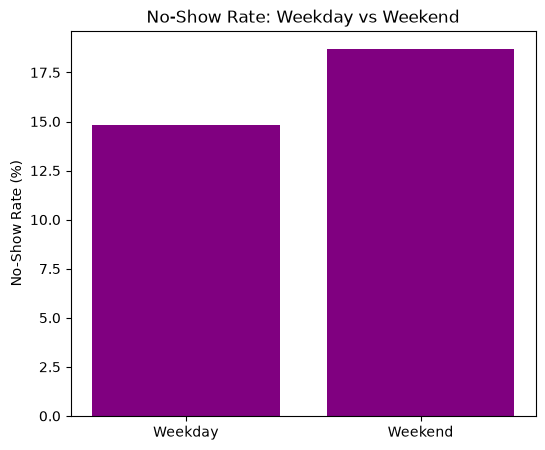

In [44]:
plt.figure(figsize=(6, 5))
plt.bar(weekend_noshow.index, weekend_noshow.values, color='purple')
plt.title('No-Show Rate: Weekday vs Weekend')
plt.xlabel('')
plt.ylabel('No-Show Rate (%)')
plt.show()

In [45]:
type_noshow = eligible.groupby('appointment_type')['no_show_flag'].mean() * 100
type_noshow = type_noshow.sort_values(ascending=False)
print(type_noshow)

appointment_type
Home Visit       26.247177
Video Consult    21.056746
In-Clinic        12.184353
Name: no_show_flag, dtype: float64


In [46]:
# Booking channel no-show rate
bchannel_noshow = eligible.groupby('booking_channel')['no_show_flag'].mean().sort_values(ascending=False) * 100
print(bchannel_noshow)

# Reminder type vs no-show
reminder_noshow = eligible.groupby('reminder_type')['no_show_flag'].mean().sort_values(ascending=False) * 100
print(reminder_noshow)

# Prior no-show history vs future no-show
eligible['had_prior_noshow'] = eligible['patient_prior_no_shows'].apply(lambda x: 'Yes' if x > 0 else 'No')
priorns_noshow = eligible.groupby('had_prior_noshow')['no_show_flag'].mean() * 100
print(priorns_noshow)

# Apollo members vs non-members
member_noshow = eligible.groupby('apollo_member')['no_show_flag'].mean() * 100
print(member_noshow)

# Repeat vs first-time patients
repeat_noshow = eligible.groupby('repeat_visit')['no_show_flag'].mean() * 100
print(repeat_noshow)

booking_channel
Walk-In        20.876253
Partner App    18.113523
Website        17.201069
Call Centre    15.200368
Apollo App     14.178652
Name: no_show_flag, dtype: float64
reminder_type
No Reminder              30.163068
SMS Only                 16.266263
SMS + WhatsApp           13.508487
SMS + WhatsApp + Call    11.410286
Name: no_show_flag, dtype: float64
had_prior_noshow
No     15.153775
Yes    21.114339
Name: no_show_flag, dtype: float64
apollo_member
No     16.888779
Yes    12.660256
Name: no_show_flag, dtype: float64
repeat_visit
No     66.782836
Yes     8.589885
Name: no_show_flag, dtype: float64


In [47]:
eligible['repeat_visit'].value_counts()

repeat_visit
Yes    63470
No      9182
Name: count, dtype: int64

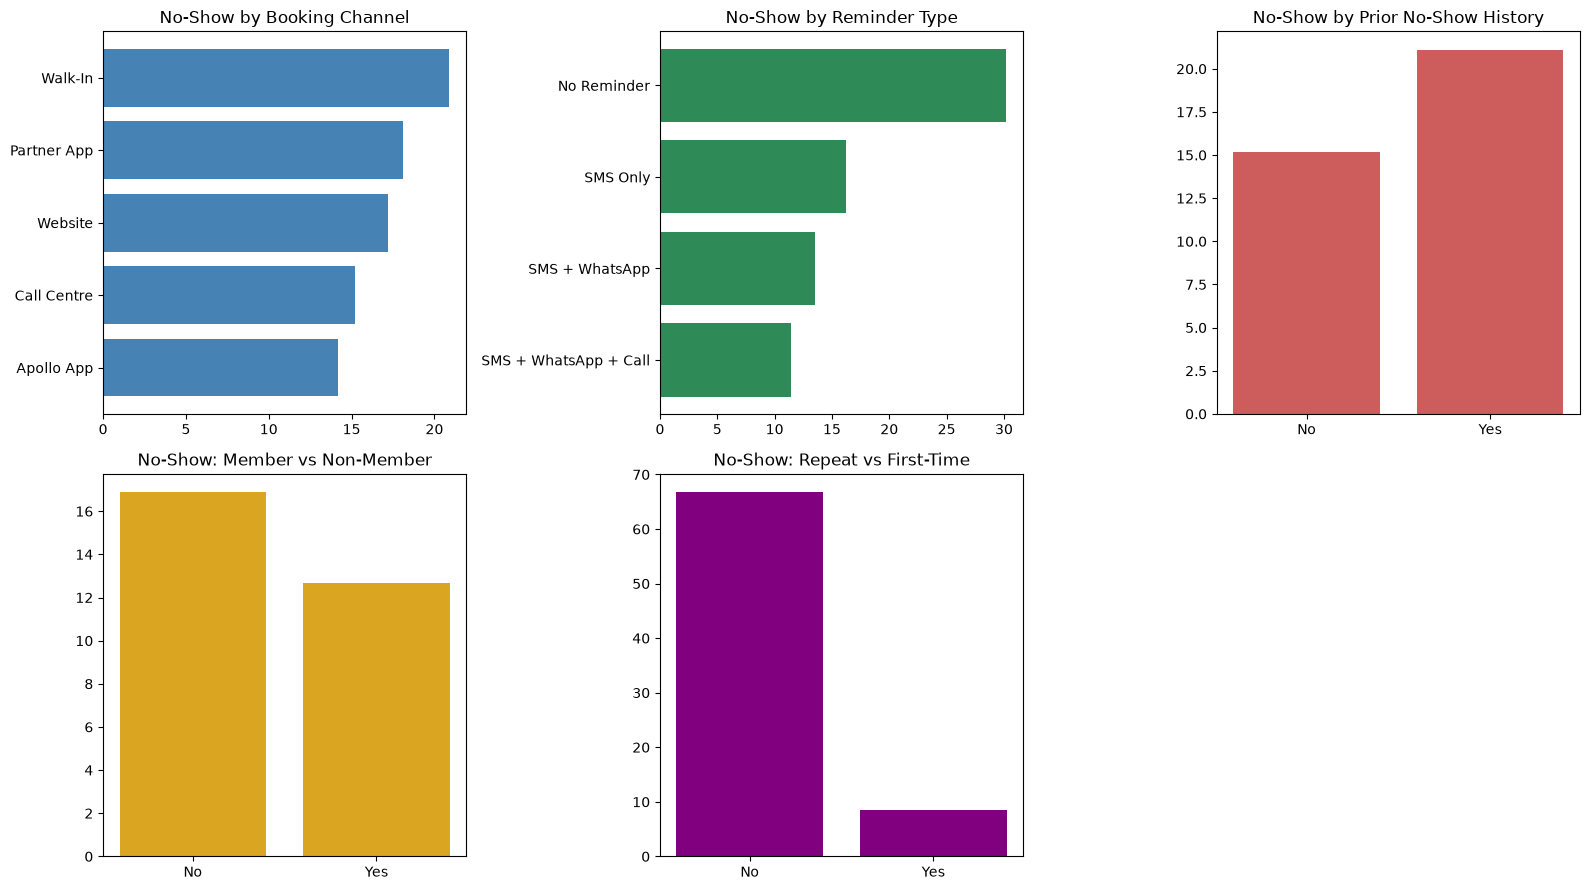

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0,0].barh(bchannel_noshow.index, bchannel_noshow.values, color='steelblue')
axes[0,0].set_title('No-Show by Booking Channel')
axes[0,0].invert_yaxis()

axes[0,1].barh(reminder_noshow.index, reminder_noshow.values, color='seagreen')
axes[0,1].set_title('No-Show by Reminder Type')
axes[0,1].invert_yaxis()

axes[0,2].bar(priorns_noshow.index, priorns_noshow.values, color='indianred')
axes[0,2].set_title('No-Show by Prior No-Show History')

axes[1,0].bar(member_noshow.index, member_noshow.values, color='goldenrod')
axes[1,0].set_title('No-Show: Member vs Non-Member')

axes[1,1].bar(repeat_noshow.index, repeat_noshow.values, color='purple')
axes[1,1].set_title('No-Show: Repeat vs First-Time')

axes[1,2].axis('off')  # empty panel, unused

plt.tight_layout()
plt.show()

In [49]:
age_noshow = eligible.groupby('age_group')['no_show_flag'].mean().sort_values(ascending=False) * 100
print(age_noshow)

age_group
Adult (31-45)          18.046653
Young Adult (19-30)    17.939503
Middle-aged (46-60)    16.760867
Teen (13-18)           14.720176
Senior (60+)           14.025902
Child (0-12)           13.537676
Name: no_show_flag, dtype: float64


In [50]:
gender_noshow = eligible.groupby('patient_gender')['no_show_flag'].mean() * 100
print(gender_noshow)

patient_gender
Female    16.039267
Male      15.842911
Name: no_show_flag, dtype: float64


In [51]:
chronic_noshow = eligible.groupby('patient_chronic_condition')['no_show_flag'].mean().sort_values(ascending=False) * 100
print(chronic_noshow)

patient_chronic_condition
Asthma            16.706969
Heart Disease     16.318951
None              15.893015
Diabetes          15.771365
Hypertension      15.571429
Hypothyroidism    15.505741
Name: no_show_flag, dtype: float64


In [52]:
visitreason_noshow = eligible.groupby('visit_reason')['no_show_flag'].mean().sort_values(ascending=False) * 100
print(visitreason_noshow)

visit_reason
Skin Issue                      16.786485
Joint Pain                      16.725924
Cardiac Concern                 16.294051
Mental Health                   16.282473
Digestive Problem               16.244990
Injury                          16.128484
Fever & Infection               16.084019
Respiratory Issue               15.979947
Women's Health                  15.961050
Routine Checkup                 15.626119
Chronic Condition Management    15.596895
Eye Care                        15.475776
Follow-up                       15.220450
Child Health                    14.644351
Name: no_show_flag, dtype: float64


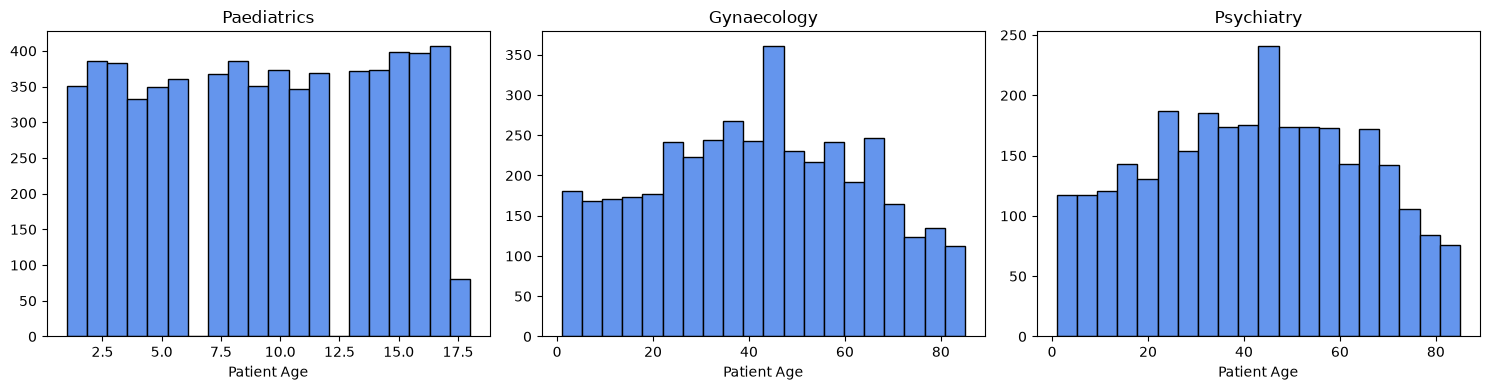

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, spec in enumerate(['Paediatrics', 'Gynaecology', 'Psychiatry']):
    data = merged[merged['specialty'] == spec]['patient_age']
    axes[i].hist(data, bins=20, color='cornflowerblue', edgecolor='black')
    axes[i].set_title(spec)
    axes[i].set_xlabel('Patient Age')

plt.tight_layout()
plt.show()

In [54]:
revenue_lost = merged[merged['appointment_status'] == 'No-Show']['consultation_fee'].sum()
print(revenue_lost)

19725460


In [55]:
total_revenue = merged[merged['appointment_status'] == 'Completed']['revenue_realized'].sum()
print(total_revenue)

pct_lost = (revenue_lost / (total_revenue + revenue_lost)) * 100
print(pct_lost)

73893798
21.069874320089145


In [56]:
completed = merged[merged['appointment_status'] == 'Completed']
specialty_revenue = completed.groupby('specialty')['revenue_realized'].mean().sort_values(ascending=False)
print(specialty_revenue)

specialty
Psychiatry           2640.447906
Neurology            2076.479354
Urology              1988.621168
Cardiology           1940.765326
Gastroenterology     1896.815923
Endocrinology        1812.684840
Pulmonology          1803.229475
Orthopaedics         1547.197899
Gynaecology          1499.591895
Ophthalmology        1467.125160
Dermatology          1306.922386
ENT                  1204.476983
Paediatrics           949.726735
General Physician     632.794006
Name: revenue_realized, dtype: float64


In [57]:
type_revenue = completed.groupby('appointment_type')['revenue_realized'].mean().sort_values(ascending=False)
print(type_revenue)

appointment_type
Home Visit       1960.048322
In-Clinic        1299.829959
Video Consult    1097.695441
Name: revenue_realized, dtype: float64


In [58]:
city_revenue = completed.groupby('city')['revenue_realized'].sum().sort_values(ascending=False)
print(city_revenue)

city
Bengaluru     9990616
Delhi         9958247
Mumbai        8989613
Hyderabad     7503245
Chennai       7188473
Kolkata       6543084
Pune          4734139
Ahmedabad     3956890
Lucknow       3177444
Indore        2223207
Chandigarh    2221091
Jaipur        2199116
Coimbatore    1792804
Kochi         1731448
Bhopal        1684381
Name: revenue_realized, dtype: int64


In [59]:
payment_mix = completed['payment_mode'].value_counts(normalize=True) * 100
print(payment_mix)

payment_mode
Insurance      21.060154
Debit Card     13.302578
Net Banking    13.295341
Apollo Pay     13.250113
UPI            13.132519
Credit Card    13.049299
Cash           12.909995
Name: proportion, dtype: float64


In [60]:
insurance_comparison = completed.groupby('insurance_coverage')[['patient_out_of_pocket', 'revenue_realized']].mean()
print(insurance_comparison)

                    patient_out_of_pocket  revenue_realized
insurance_coverage                                         
No                            1562.820670       1562.820670
Yes                            859.175192        859.175192


In [61]:
insurance_check = completed.groupby('insurance_coverage')[['insurance_covered_amount', 'patient_out_of_pocket', 'revenue_realized']].mean()
print(insurance_check)

                    insurance_covered_amount  patient_out_of_pocket  \
insurance_coverage                                                    
No                                  0.000000            1562.820670   
Yes                               697.173896             859.175192   

                    revenue_realized  
insurance_coverage                    
No                       1562.820670  
Yes                       859.175192  


In [62]:
utilisation_specialty = completed.groupby('specialty')['doctor_utilization_pct'].mean().sort_values(ascending=False)
print(utilisation_specialty)

specialty
Gastroenterology     77.256288
Endocrinology        77.146277
Cardiology           76.814200
Gynaecology          76.804531
Paediatrics          76.664143
Neurology            76.632342
General Physician    76.590615
Urology              76.442568
Orthopaedics         76.430485
Dermatology          76.420516
Pulmonology          76.354615
ENT                  76.327542
Ophthalmology        76.193401
Psychiatry           76.181052
Name: doctor_utilization_pct, dtype: float64


In [63]:
wait_specialty = completed.groupby('specialty')['wait_time_minutes'].mean().sort_values(ascending=False)
print(wait_specialty)

wait_time_of_day = completed.groupby('time_of_day')['wait_time_minutes'].mean().sort_values(ascending=False)
print(wait_time_of_day)

specialty
Ophthalmology        12.017454
Urology              11.905147
Dermatology          11.771648
Orthopaedics         11.701838
Neurology            11.638112
Gynaecology          11.616784
Cardiology           11.594240
General Physician    11.531807
Endocrinology        11.459441
Gastroenterology     11.390467
Pulmonology          11.385518
Psychiatry           11.338611
ENT                  11.298049
Paediatrics          11.175510
Name: wait_time_minutes, dtype: float64
time_of_day
Afternoon    11.552577
Evening      11.551782
Morning      11.546854
Name: wait_time_minutes, dtype: float64


In [64]:
corr = completed['consultation_duration_min'].corr(completed['patient_satisfaction_score'])
print(corr)

-0.0035053235594283087


In [65]:
corr2 = merged['experience_years'].corr(merged['consultation_fee_doc'])
print(corr2)

0.27559756320309836


In [66]:
## 7. Final Report

In [67]:
### KPI Summary

| What we're measuring | Number |
|---|---|
| Total Appointments | 75,000 |
| Completed | 55,275 |
| No-Show | 11,584 |
| Cancelled | 5,793 |
| Scheduled (not happened yet) | 2,348 |
| Overall No-Show Rate | 15.9% |
| Money Lost to No-Shows | ₹1,97,25,460 |
| % of Revenue Lost | 21.1% |
| Average Wait Time | ~11.6 minutes |

In [68]:
print(completed['patient_satisfaction_score'].mean())

4.068092265943012


In [69]:
### Key Findings

- Psychiatry patients skip appointments the most (24.5%). Neurology patients skip the least (10.7%)
- Lucknow has the most no-shows by city (17.2%). Pune has the fewest (13.3%)
- The longer someone books in advance, the more likely they are to skip: 14.3% (booked 1-3 days early) vs 19.1% (booked 8-30 days early)
- Evening appointments get skipped more (18.4%) than morning ones (13.7%)
- Weekends see more no-shows (18.7%) than weekdays (14.8%)
- Home Visits are skipped most often (26.2%). In-Clinic visits are skipped least (12.2%)
- Reminders really help: no reminder = 30.2% skip rate, full reminder (SMS+WhatsApp+Call) = only 11.4%
- Patients who skipped before are more likely to skip again (21.1% vs 15.2%)
- Apollo members show up more reliably than non-members (12.7% vs 16.9% skip rate)
- Returning patients are far more reliable than first-timers (8.6% vs 66.8% skip rate)

In [70]:
### Business Recommendations

1. Make the full reminder bundle (SMS + WhatsApp + Call) required for every booking, not optional
2. Call patients to confirm if they booked 8+ days in advance
3. Ask for a deposit or extra confirmation for evening and weekend slots
4. Add an extra confirmation step just for Home Visit bookings
5. Encourage more people to book through the Apollo App — it has the lowest skip rate
6. Send extra reminders to patients who have skipped before

In [71]:
### Conclusion

No-shows are costing Apollo about ₹1.97 crore — roughly 21% of the revenue it could have earned. The biggest risk factors are long booking lead times, evening/weekend slots, and Home Visit appointments. Reminders make the single biggest difference in whether a patient shows up. Focusing reminder effort on these high-risk groups should meaningfully cut losses.